# **MScFE 690: CapstoneProject**
## **Influence Diagram as A Decision-Making Tool for Factor Investing**
### Student Group: **11186**
#### Members:
1. **Vahid Nikoofard**
2. **Dipanshu Sharma**
3. **Rhesa Prabowo Budhidarmo**


In [ ]:
# installing the required packages

In [2]:
# importing the required packages and libraries

import io, os, sys, math, datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import openassetpricing as oap

import warnings 
warnings.filterwarnings('ignore')

/opt/anaconda3/envs/py312/lib/python3.12/site-packages/seaborn/_statistics.py:32: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.3.1)
  from scipy.stats import gaussian_kde


In [3]:
# master project path
# base_path = "/Users/sharmadipanshu/Developer/MScFE 2509 Capstone/WQU_Capstone_Project/MScFE_WQU_Capstone_Project"
base_path = '../'
# defining subpaths
inputs_raw = f"{base_path}/inputs/raw"
inputs_clean = f"{base_path}/inputs/clean"
outputs_eda = f"{base_path}/outputs/eda"
meta_path = f"{base_path}/inputs/meta"

In [4]:
# defining the required custom functions

## **Step 1: Exploratory Data Analysis (EDA) / ETL (Extract, Transfom and Load)**

In [5]:
# initializing openap for downloading the dataset
openap = oap.OpenAP()
openap.list_port() 

┌─────────────────────────────────────────────────┬─────────────────────┐
│ CZ portfolio file                               │ Name for download   │
├─────────────────────────────────────────────────┼─────────────────────┤
│ PredictorAltPorts_Deciles.zip                   │ deciles_ew          │
│ PredictorAltPorts_DecilesVW.zip                 │ deciles_vw          │
│ PredictorAltPorts_LiqScreen_ME_gt_NYSE20pct.zip │ ex_nyse_p20_me      │
│ PredictorAltPorts_LiqScreen_NYSEonly.zip        │ nyse                │
│ PredictorAltPorts_LiqScreen_Price_gt_5.zip      │ ex_price5           │
│ PredictorAltPorts_Quintiles.zip                 │ quintiles_ew        │
│ PredictorAltPorts_QuintilesVW.zip               │ quintiles_vw        │
│ PredictorPortsFull.csv                          │ op                  │
└─────────────────────────────────────────────────┴─────────────────────┘


In [ ]:
# downloading the selected factors, 
# BM (Book-to-Market), Mom12m (12-month Momentum), Size (Market Equity), OP (Operating Profitability), Investment, IdioVol3F (idiosyncratic volatility residualized vs 3-factor model)
# using value-weighted quintile portfolios
factors = ['BM', 'Mom12m', 'Size', 'OperProf', 'Investment', 'IdioVol3F'] 
port_name = 'quintiles_vw'

osap_df = openap.dl_port(port_name, 'pandas', factors=factors)
osap_df.head()


Data is downloaded: 9s


,signalname,port,date,ret,signallag,Nlong,Nshort
0,BM,01,1951-07-31,6.324465,-0.921486,65,0
1,BM,01,1951-08-31,4.121121,-0.919069,65,0
2,BM,01,1951-09-28,0.393433,-0.917030,65,0
3,BM,01,1951-10-31,-5.521909,-0.912968,65,0
4,BM,01,1951-11-30,0.624145,-0.910410,65,0


In [ ]:
osap_df.port.unique()
# LS is the long-short portfolio, which can we used as factor returns directly

array(['01', '02', '03', '04', '05', 'LS'], dtype=object)

In [ ]:
# filter for LS (long short) port and selected factors
mask = (osap_df['port'].astype(str).str.upper() == 'LS') & (osap_df['signalname'].isin(factors))
ls_df = osap_df.loc[mask, ['signalname', 'date', 'ret']].copy()

# pivot to wide: index=date, columns=signalname, values=ret
osap_factor_returns = ls_df.pivot(index='date', columns='signalname', values='ret')
osap_factor_returns.head()

signalname,BM,IdioVol3F,Investment,Mom12m,OperProf,Size
date,,,,,,
1926-07-31,NaN,NaN,NaN,NaN,NaN,-3.193279
1926-08-31,NaN,3.337295,NaN,NaN,NaN,-0.347584
1926-09-30,NaN,2.434277,NaN,NaN,NaN,-2.532196
1926-10-30,NaN,3.838838,NaN,NaN,NaN,0.053298
1926-11-30,NaN,2.732623,NaN,NaN,NaN,-3.435825


In [24]:
# filtering the common period from where all factor return data is available 
start_date = osap_factor_returns.dropna().index.min()
end_date = osap_factor_returns.dropna().index.max()
print("Common period with all factor returns available:", start_date, "to", end_date)

osap_factor_returns = osap_factor_returns.loc[start_date:end_date]
osap_factor_returns.head()

Common period with all factor returns available: 1963-07-31 00:00:00 to 2023-12-29 00:00:00


signalname,BM,IdioVol3F,Investment,Mom12m,OperProf,Size
date,,,,,,
1963-07-31,-1.604886,1.495143,-2.350293,4.002945,1.794396,-0.152139
1963-08-30,0.746853,0.266533,2.854979,2.079637,-0.141245,-2.302976
1963-09-30,-0.480310,0.706279,1.740518,-0.021432,1.216438,2.063559
1963-10-31,-4.190955,-0.075028,2.090986,4.084196,6.823304,-2.537646
1963-11-29,0.978539,1.992771,1.257039,-2.436076,-3.956558,-2.687290


In [25]:
# checking the missing values, data types and shape of the dataset
display(osap_factor_returns.info())
display(osap_factor_returns.isna().sum())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 726 entries, 1963-07-31 to 2023-12-29
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   BM          726 non-null    float64
 1   IdioVol3F   726 non-null    float64
 2   Investment  726 non-null    float64
 3   Mom12m      726 non-null    float64
 4   OperProf    726 non-null    float64
 5   Size        726 non-null    float64
dtypes: float64(6)
memory usage: 39.7 KB


None

signalname
BM            0
IdioVol3F     0
Investment    0
Mom12m        0
OperProf      0
Size          0
dtype: int64

In [26]:
# storing the cleaned dataset in inputs/clean folder 
osap_factor_returns.to_csv(f"{inputs_clean}/osap_factor_returns.csv", index=True)

### **Step 1.1- Summary Statistics and Distributions**

In [27]:
# summary statistics + higher moments
osap_returns_summary_stats = osap_factor_returns.describe().T
osap_returns_summary_stats['skew'] = osap_factor_returns.skew()
osap_returns_summary_stats['kurtosis'] = osap_factor_returns.kurtosis()
osap_returns_summary_stats['n_obs'] = osap_factor_returns.count()
osap_returns_summary_stats['n_nan'] = osap_factor_returns.isna().sum()

# saving the summary stats
osap_returns_summary_stats.to_csv(os.path.join(outputs_eda, "osap_returns_summary_stats.csv"))

# display
display(osap_returns_summary_stats)

,count,mean,std,min,25%,50%,75%,max,skew,kurtosis,n_obs,n_nan
signalname,,,,,,,,,,,,
BM,726.0,0.343922,3.476208,-17.647239,-1.870591,0.278564,2.423063,16.170049,0.017659,2.211396,726,0
IdioVol3F,726.0,0.716489,6.618949,-31.185234,-2.611683,0.986328,4.227749,35.328842,-0.133507,4.329423,726,0
Investment,726.0,0.187782,2.734095,-12.695940,-1.300412,0.121244,1.673775,27.034728,1.249385,14.619942,726,0
Mom12m,726.0,0.901550,6.458141,-45.656028,-1.819608,1.411723,4.302130,23.613449,-1.222371,6.772714,726,0
OperProf,726.0,0.296314,3.736219,-14.603810,-1.809136,0.184961,2.487038,23.490974,0.332259,3.537475,726,0
Size,726.0,0.038208,5.422301,-18.703086,-2.897808,-0.321762,2.551256,29.026841,0.914371,3.654880,726,0


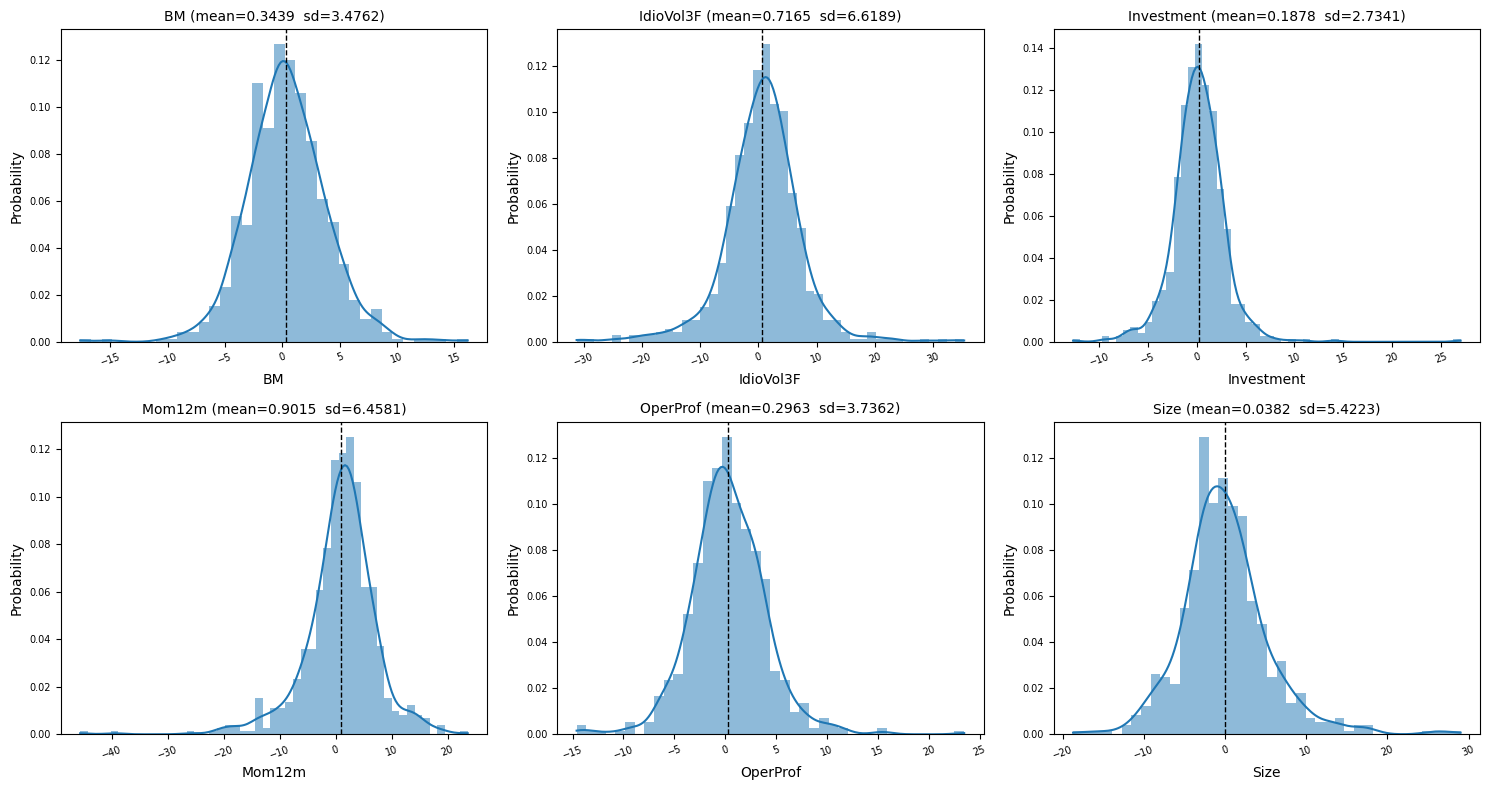

In [28]:
# plotting combined grid: histograms + KDE line for all factors monthly returns series
cols = osap_factor_returns.columns.tolist()
n, ncols = len(cols), 3
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
axes = axes.flatten()

for i, col in enumerate(cols):
    ax = axes[i]
    data = osap_factor_returns[col]
    if len(data) == 0:
        ax.set_visible(False)
        continue
    sns.histplot(data, kde=True, ax=ax, stat="probability", edgecolor=None)
    ax.set_title(f"{col} (mean={data.mean():.4f}  sd={data.std():.4f})", fontsize=10)
    ax.axvline(data.mean(), color='k', linestyle='--', linewidth=1)
    ax.tick_params(axis='x', rotation=20)
    ax.tick_params(labelsize=7)

# turning off any extra axes
for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
grid_png = os.path.join(outputs_eda, "osap_factor_returns_distributions_grid.png")
fig.savefig(grid_png, dpi=300, bbox_inches='tight')
plt.show()

### **Step 1.2- Correlation Analysis**

### **Step 1.3- Time Series Plots**

### **Step 1.4- Autocorrelation**

### **Step 1.5- Information Coefficient (IC) and Stationarity Tests**